# 03 - Exploratory Data Analysis: Meeting Cost & Burn Score

This notebook loads the two SQL query outputs produced earlier in the
project and turns them into exploratory charts for the README/interview.

**Inputs (`data/processed/`):**
- `meeting_costs.csv` — one row per meeting, from the `meeting_costs` view
  in `sql/meeting_cost_rollup.sql` (columns: `meeting_id, meeting_date,
  department_id, department_name, meeting_type, organizer_seniority,
  is_recurring, duration_hours, attendee_count, meeting_cost`).
- `meeting_burn_scores.csv` — one row per meeting, from the STEP 1-4 query
  in `sql/meeting_value_score.sql` (adds `type_points, attendee_bloat_ratio,
  attendee_bloat_points, recurring_points, raw_burn_points,
  meeting_burn_score`, `meeting_burn_score` 1-5 where 5 = worst offender).

**Outputs (`images/`):**
- `monthly_cost_trend.png`
- `cost_by_department.png`
- `cost_distribution_by_meeting_type.png`
- `burn_score_distribution.png`


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROCESSED_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

meeting_costs = pd.read_csv(PROCESSED_DIR / "meeting_costs.csv", parse_dates=["meeting_date"])
burn_scores = pd.read_csv(PROCESSED_DIR / "meeting_burn_scores.csv", parse_dates=["meeting_date"])

print(f"meeting_costs : {len(meeting_costs):,} rows, {meeting_costs['meeting_date'].min().date()} to {meeting_costs['meeting_date'].max().date()}")
print(f"burn_scores   : {len(burn_scores):,} rows")
meeting_costs.head()


meeting_costs : 55,948 rows, 2024-01-01 to 2026-06-26
burn_scores   : 55,948 rows


,meeting_id,meeting_date,department_id,meeting_type,organizer_seniority,is_recurring,duration_hours,attendee_count,meeting_cost,department_name
0,1,2024-01-03,5,status_update,mid,0,0.683333,7,4087.56,Operations
1,2,2024-01-03,1,decision_making,senior,0,0.500000,6,2533.28,Engineering
2,3,2024-01-05,1,status_update,senior,0,0.250000,6,679.52,Engineering
3,4,2024-01-03,1,brainstorm,mid,0,1.016667,2,2052.32,Engineering
4,5,2024-01-01,3,one_on_one,senior,1,0.700000,2,508.32,HR


## Chart 1: Monthly cost trend

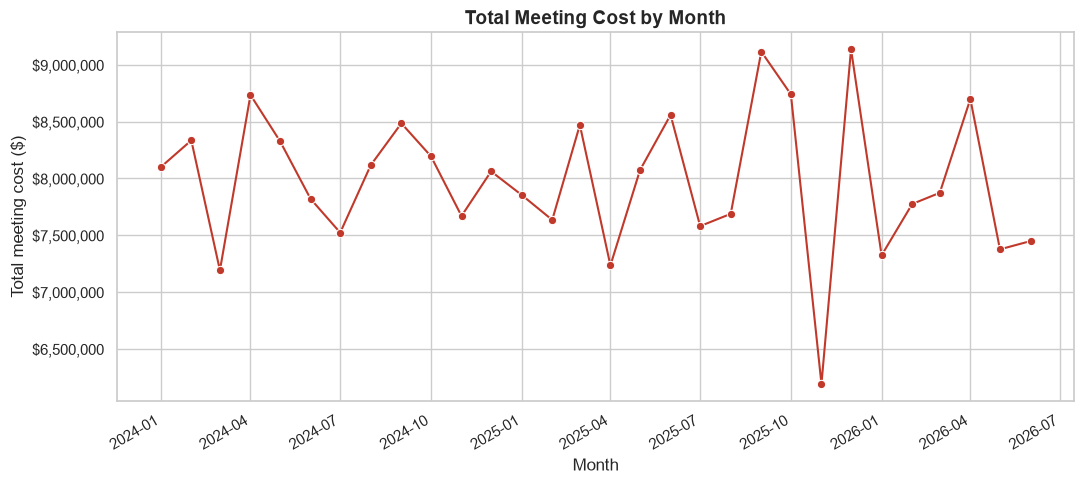

In [2]:
monthly_cost = (
    meeting_costs
    .assign(year_month=meeting_costs["meeting_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("year_month", as_index=False)["meeting_cost"]
    .sum()
    .sort_values("year_month")
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=monthly_cost, x="year_month", y="meeting_cost", marker="o", ax=ax, color="#c0392b")
ax.set_title("Total Meeting Cost by Month", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total meeting cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(IMAGES_DIR / "monthly_cost_trend.png", dpi=150)
plt.show()


**What this shows:** total meeting spend by calendar month across the full
dataset window (Jan 2024 – Jun 2026). Cost hovers in a persistent
~$7.2M–$9.1M/month band (average ≈ $8.0M/month) with no long-run upward or
downward trend — this is a steady, structural overhead rather than a
one-off spike tied to a single event, which is exactly the "always-on tax"
framing this project is built around. The single sharpest swing is a dip
to $6.2M in Nov 2025 immediately followed by the year's peak of $9.1M in
Dec 2025 — a pattern worth naming explicitly (e.g. a holiday lull followed
by a year-end planning/review crunch) since seasonal spikes like this are
the easiest wins to point to when arguing for meeting reduction.

## Chart 2: Cost by department

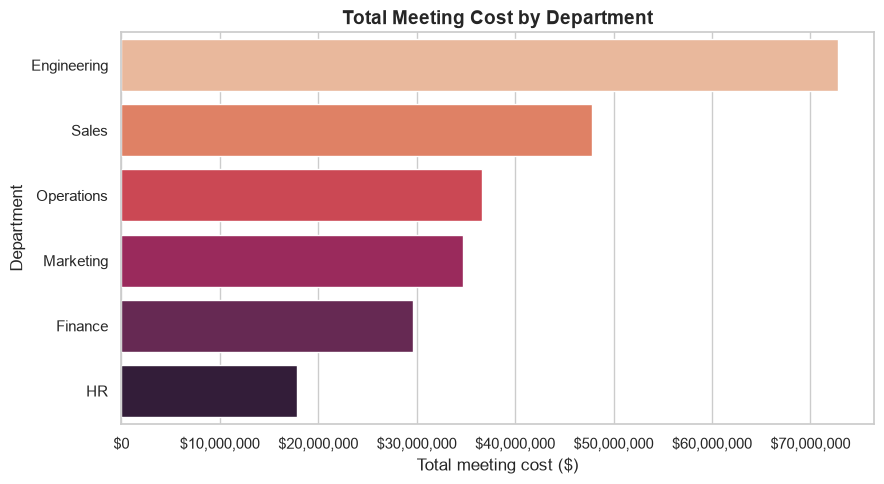

In [3]:
cost_by_dept = (
    meeting_costs
    .groupby("department_name", as_index=False)["meeting_cost"]
    .sum()
    .sort_values("meeting_cost", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=cost_by_dept,
    x="meeting_cost",
    y="department_name",
    hue="department_name",
    palette="rocket_r",
    legend=False,
    ax=ax,
)
ax.set_title("Total Meeting Cost by Department", fontsize=14, fontweight="bold")
ax.set_xlabel("Total meeting cost ($)")
ax.set_ylabel("Department")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
fig.tight_layout()
fig.savefig(IMAGES_DIR / "cost_by_department.png", dpi=150)
plt.show()


**What this shows:** which departments carry the largest share of total
meeting spend. Engineering tops the list at ~$72.8M, roughly 4.1x HR's
~$17.9M — the smallest department here. This is a headcount/seniority-mix
effect as much as a behavior effect: a department at the top of this chart
isn't necessarily "worse" at meetings, it may just be bigger or more
senior-heavy — so this chart is best paired with `avg_cost_per_meeting`
(from the SQL rollups) before assigning blame to any one team.

## Chart 3: Cost distribution by meeting type

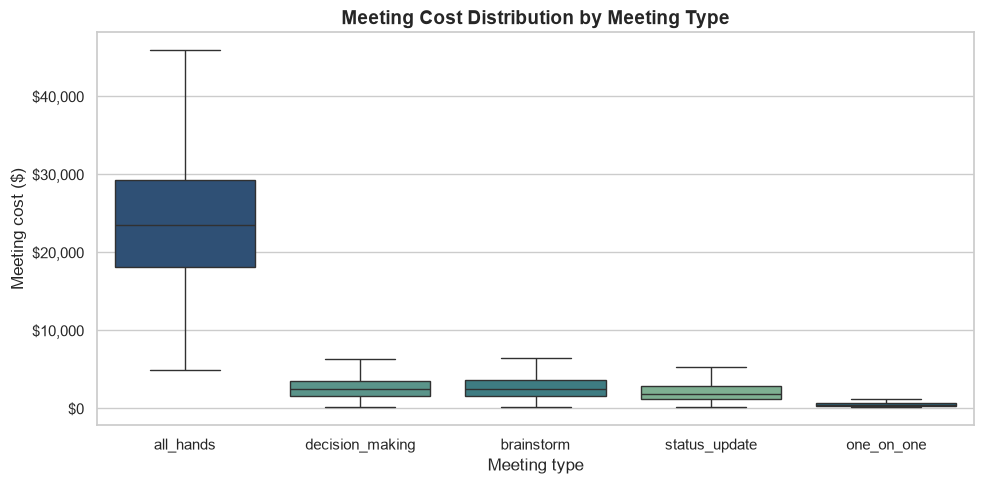

In [4]:
type_order = (
    meeting_costs.groupby("meeting_type")["meeting_cost"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=meeting_costs,
    x="meeting_type",
    y="meeting_cost",
    order=type_order,
    hue="meeting_type",
    palette="crest",
    legend=False,
    showfliers=False,
    ax=ax,
)
ax.set_title("Meeting Cost Distribution by Meeting Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Meeting type")
ax.set_ylabel("Meeting cost ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
fig.tight_layout()
fig.savefig(IMAGES_DIR / "cost_distribution_by_meeting_type.png", dpi=150)
plt.show()


**What this shows:** the spread (not just the average) of cost within each
meeting type — box edges mark the 25th/75th percentiles, the line is the
median, and extreme outliers are hidden (`showfliers=False`) so the typical
range isn't squashed. `all_hands` dwarfs every other category, with a
median cost (~$23,400) roughly 51x that of `one_on_one` (~$460) — driven
almost entirely by attendee count, since these meetings broadcast to large
audiences. `decision_making` and `brainstorm` land in a similar mid-range
(~$2,400–$2,450 median), while `status_update` (~$1,870 median) still
shows a wide box — signaling the category is used inconsistently, with
some quick syncs and others that have quietly grown into large, expensive
standing meetings.

## Chart 4: Meeting Burn Score distribution

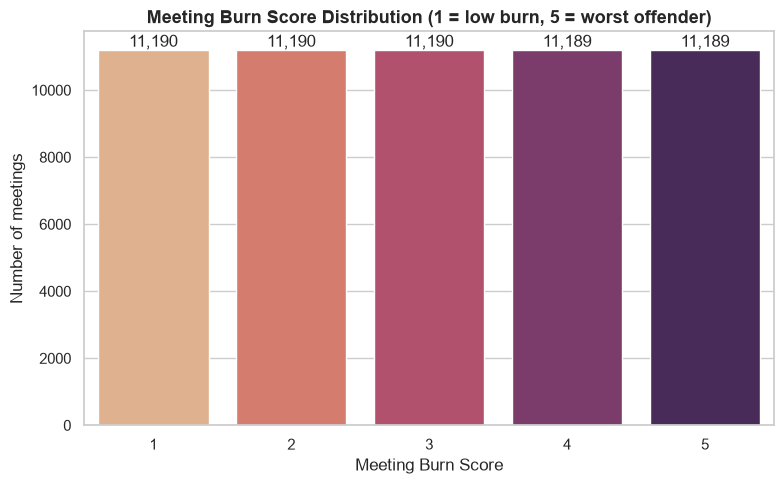

In [5]:
burn_counts = (
    burn_scores["meeting_burn_score"]
    .value_counts()
    .sort_index()
    .rename_axis("meeting_burn_score")
    .reset_index(name="n_meetings")
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=burn_counts,
    x="meeting_burn_score",
    y="n_meetings",
    hue="meeting_burn_score",
    palette="flare",
    legend=False,
    ax=ax,
)
ax.set_title("Meeting Burn Score Distribution (1 = low burn, 5 = worst offender)", fontsize=13, fontweight="bold")
ax.set_xlabel("Meeting Burn Score")
ax.set_ylabel("Number of meetings")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "burn_score_distribution.png", dpi=150)
plt.show()


**What this shows:** how many meetings fall into each burn-score bucket.
Because the score is built with `NTILE(5)`, the five bars come out almost
perfectly even (~11,190 meetings each, ~20% per bucket) — confirming the
score isn't degenerate (e.g. everything dumped into one bucket). The real
story isn't in the bar heights here, it's in *which* meetings land in
bucket 5 — surfaced separately by the "top 10 offenders" query in
`sql/meeting_value_score.sql`, which is the number to lead with in the
README/interview.

## Summary

Charts saved to `images/`:
1. `monthly_cost_trend.png` — total meeting spend by month
2. `cost_by_department.png` — total meeting spend by department
3. `cost_distribution_by_meeting_type.png` — cost spread per meeting type
4. `burn_score_distribution.png` — count of meetings per Burn Score bucket
